In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Import data
def import_data(data_name: str):
    """Data importing function for ease of use

    Args:
        data_name (str): Name of the dataset to work with
    """
    if data_name == "vahid-linear":
        rmses = {
            "uniform_all": pd.read_csv(
                "../output/11-21/RMSE_table_vahid-linear_uniform_all_11-21_15h23m.csv",
                index_col=[0]
            ),
            "quantile_all": pd.read_csv(
                "../output/11-21/RMSE_table_vahid-linear_quantile_all_11-21_15h23m.csv",
                index_col=[0]
            ),
            "uniform_sequential": pd.read_csv(
                "../output/11-17_to_11-18/RMSE_table_vahid-linear_11-18_17h18m.csv",
                index_col=[0]
            ),
            "quantile_sequential": pd.read_csv(
                "../output/11-17_to_11-18/quantile_RMSE_table_vahid-linear_11-18_18h8m.csv",
                index_col=[0]
            )
        }
    else: 
        raise ValueError(f"data_name unrecognized: {data_name}")
    
    return rmses

1


In [ ]:
data_name = "vahid-linear"
rmses = import_data(data_name=data_name)

In [57]:
best_rmse = {}
for data in rmses:
    df = rmses[data]
    df_best = df[df["RMSE"].values == df.min().values]
    N_best = df_best.index.item()
    rmse_best = df_best.values.item()
    best_rmse[f"{data}\nN_DISC={N_best}"] = rmse_best
    

In [58]:
list(zip(*best_rmse.items()))

[('uniform_all\nN_DISC=6',
  'quantile_all\nN_DISC=23',
  'uniform_sequential\nN_DISC=7',
  'quantile_sequential\nN_DISC=21'),
 (0.20755, 0.21511, 0.08145, 0.18348)]

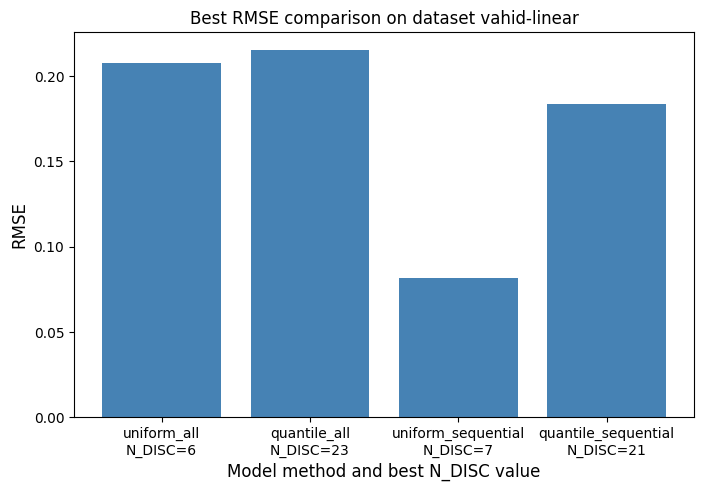

In [62]:
fig = plt.figure(figsize=(8, 5))

plt.bar(*zip(*best_rmse.items()), color="steelblue")
plt.xlabel("Model method and best N_DISC value", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title(f"Best RMSE comparison on dataset {data_name}")

plt.savefig(f"../output/11-21/best_rmse_comparison_{data_name}.png", dpi=300, bbox_inches="tight")

plt.show()